In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Dense, Input

### Task 1: Data Loading, Cleaning & Exploratory Data Analysis

In [3]:
# 1.1 Load and inspect the dataset

df = pd.read_csv('Dataset/adult.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nData types: \n{df.dtypes}")


Dataset shape: (48842, 15)

Data types: 
age                int64
workclass            str
fnlwgt             int64
education            str
educational-num    int64
marital-status       str
occupation           str
relationship         str
race                 str
gender               str
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country       str
income               str
dtype: object


In [4]:
display(df.head())

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
for col in df.select_dtypes('str'):
  df[col] = df[col].str.strip()
print('Whitespace removed.')

Whitespace removed.


In [6]:
# 1.2 Handle missing values

df.replace('?', np.nan, inplace = True)
print('Missing values per column: ')
print(df.isnull().sum().sort_values(ascending = False))

rows_before = len(df)
df.dropna(inplace = True)
rows_after = len(df)

print(f"\nTotal rows removed: {rows_before - rows_after}")

Missing values per column: 
occupation         2809
workclass          2799
native-country      857
fnlwgt                0
education             0
educational-num       0
age                   0
marital-status        0
relationship          0
gender                0
race                  0
capital-gain          0
capital-loss          0
hours-per-week        0
income                0
dtype: int64

Total rows removed: 3620


In [7]:
# 1.3 Drop reduntant columns

df.drop(columns = ['fnlwgt', 'education'], inplace = True)
print(f"Dataset shape after dropping columns: {df.shape}")

Dataset shape after dropping columns: (45222, 13)


Value count of 'income': 
income
0    34014
1    11208
Name: count, dtype: int64


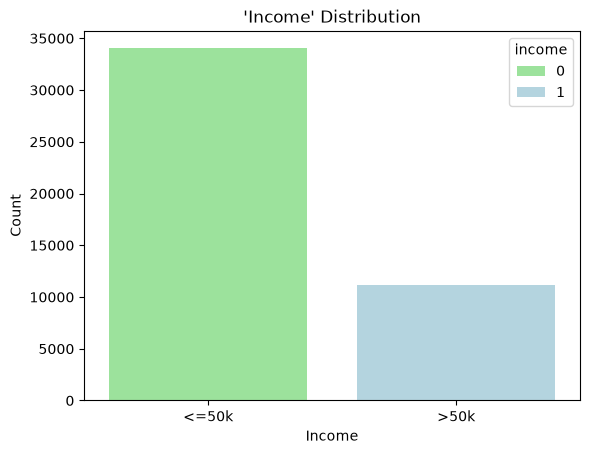

In [8]:
# 1.4 Encode the target

df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
print(f"Value count of 'income': \n{df['income'].value_counts()}")

sns.countplot(data = df, x = 'income', hue = 'income',palette = ['lightgreen', 'lightblue'])
plt.title("'Income' Distribution")
plt.xlabel('Income')
plt.ylabel('Count')

plt.xticks([0, 1], ['<=50k', '>50k'])
plt.show()

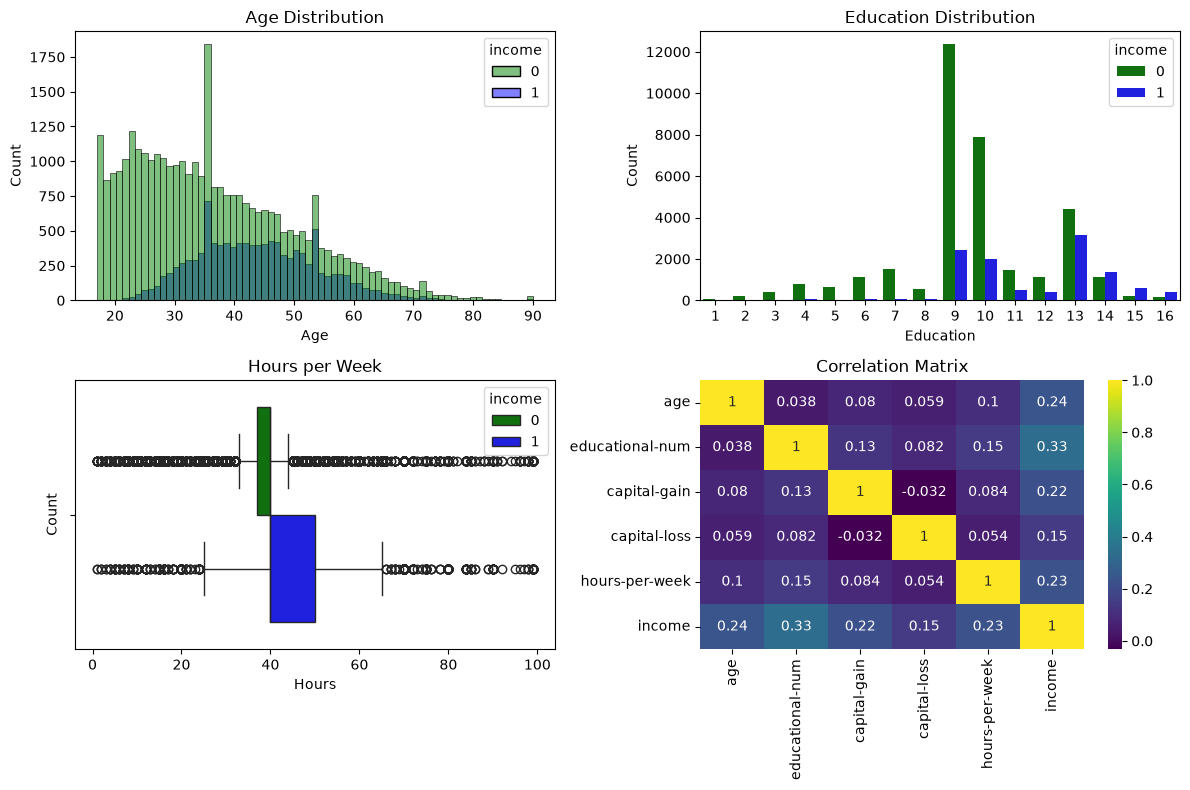

In [9]:
# 1.5 Exploratory visualisations

fig, ax = plt.subplots(2, 2, figsize = (12, 8))

sns.histplot(data = df, x = 'age', hue = 'income', palette = ['green', 'blue'],ax = ax[0,0])
ax[0,0].set_title('Age Distribution')
ax[0,0].set_xlabel('Age')
ax[0,0].set_ylabel('Count')

sns.boxplot(data = df, x = 'hours-per-week' ,hue = 'income', palette = ['green', 'blue'],ax = ax[1,0])
ax[1,0].set_title('Hours per Week')
ax[1,0].set_xlabel('Hours')
ax[1,0].set_ylabel('Count')

sns.countplot(data = df, x = 'educational-num', hue = 'income', palette = ['green', 'blue'],ax = ax[0,1])
ax[0,1].set_title('Education Distribution')
ax[0,1].set_xlabel('Education')
ax[0,1].set_ylabel('Count')

sns.heatmap(df.corr(numeric_only = True), cmap = 'viridis', annot = True ,ax = ax[1,1])
ax[1,1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [10]:
# 1.6 Encode categoricals & scale numerics

X = df.drop('income', axis = 1)
y = df['income']

X = pd.get_dummies(X, drop_first=True)
print("Shape after One-Hot Encoding:", X.shape)

numeric_cols = [
    'age',
    'educational-num',
    'hours-per-week',
    'capital-gain',
    'capital-loss',
]

se = StandardScaler()
X[numeric_cols] = se.fit_transform(X[numeric_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 9009, stratify = y)

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Shape after One-Hot Encoding: (45222, 80)

X_train shape: (36177, 80)
X_test shape: (9045, 80)
y_train shape: (36177,)
y_test shape: (9045,)


In [11]:
print("\nOriginal class ratio:")
print(y.value_counts(normalize=True).round(2))

print("\nTraining class ratio:")
print(y_train.value_counts(normalize=True).round(2))

print("\nTesting class ratio:")
print(y_test.value_counts(normalize=True).round(2))


Original class ratio:
income
0    0.75
1    0.25
Name: proportion, dtype: float64

Training class ratio:
income
0    0.75
1    0.25
Name: proportion, dtype: float64

Testing class ratio:
income
0    0.75
1    0.25
Name: proportion, dtype: float64


### Task 2: MLP Architecture - Baseline ANN

In [12]:
# 2.1 Define the reusable build_ann() function

def build_ann(input_dim, hidden_units = [128, 64], activation = 'relu', initializer = 'glorot_uniform', use_batch_norm = False,  optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy']):

    model = Sequential()
    model.add(Input(shape = (input_dim,)))

    for unit in hidden_units:
        model.add(Dense(unit, activation = activation, kernel_initializer = initializer))

    model.add(Dense(1, activation = 'sigmoid'))

    model.compile(loss = loss, optimizer = optimizer, metrics = metrics)

    return model


In [13]:
X_train.shape[1]

80

In [14]:
# 2.2 Baseline ANN architecture

model_base = build_ann(input_dim = X_train.shape[1])

model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,689 (73.00 KB)

 Trainable params: 18,689 (73.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 2.3 Train the baseline

history_base = model_base.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1 ,verbose = 1)

Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8382 - loss: 0.3407 - val_accuracy: 0.8480 - val_loss: 0.3217
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8524 - loss: 0.3165 - val_accuracy: 0.8485 - val_loss: 0.3213
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8544 - loss: 0.3120 - val_accuracy: 0.8485 - val_loss: 0.3203
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8557 - loss: 0.3097 - val_accuracy: 0.8499 - val_loss: 0.3208
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8568 - loss: 0.3064 - val_accuracy: 0.8488 - val_loss: 0.3214
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8596 - loss: 0.3040 - val_accuracy: 0.8507 - val_loss: 0.3238
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8597 - loss: 0.3019 - val_accuracy: 0.8466 - val_loss: 0.3246
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8614 - loss: 0.2990 - val_accuracy: 0.

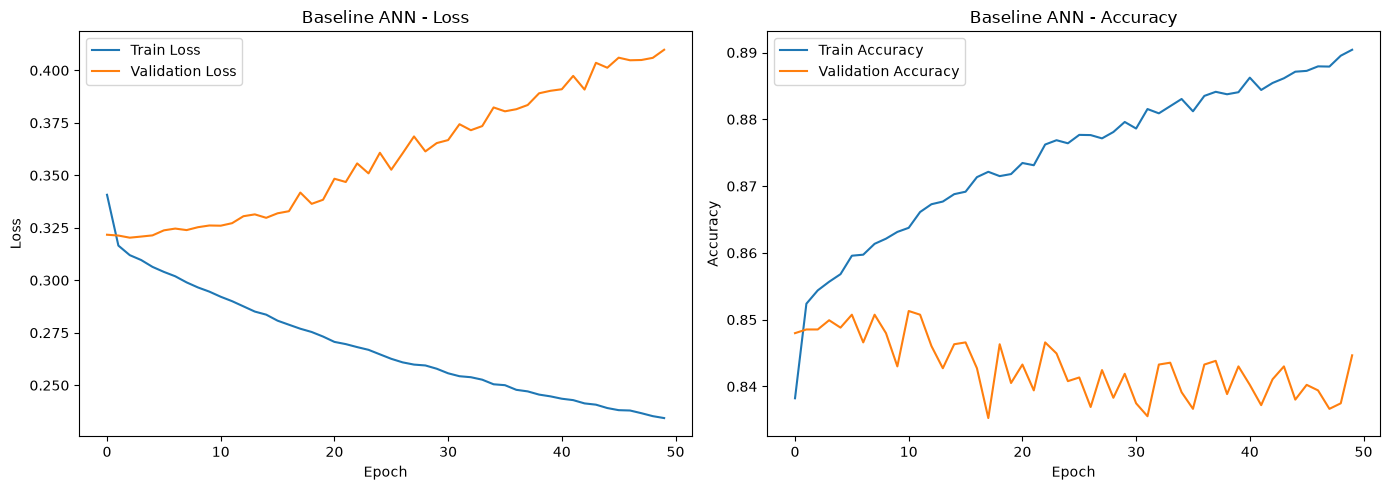

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


ax[0].plot(history_base.history['loss'], label='Train Loss')
ax[0].plot(history_base.history['val_loss'], label='Validation Loss')
ax[0].set_title('Baseline ANN - Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()


ax[1].plot(history_base.history['accuracy'], label='Train Accuracy')
ax[1].plot(history_base.history['val_accuracy'], label='Validation Accuracy')
ax[1].set_title('Baseline ANN - Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# 2.4 Evaluate the baseline with full metrics

y_pred_prob = model_base.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred))

283/283 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      6803
           1       0.70      0.66      0.68      2242

    accuracy                           0.84      9045
   macro avg       0.79      0.78      0.79      9045
weighted avg       0.84      0.84      0.84      9045



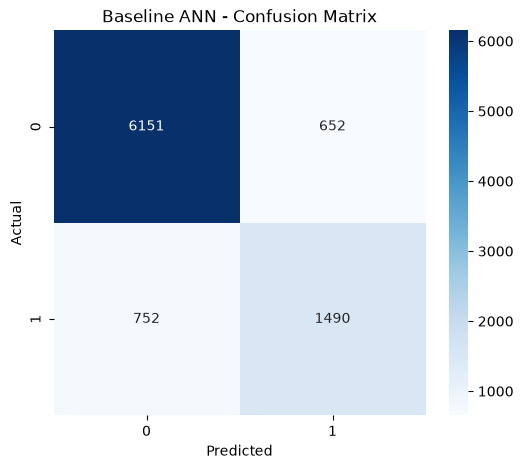

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Baseline ANN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [19]:
# 2.5

### Task 3: Activation Functions - Comparison Experiment

In [20]:
# 3.1 Train 4 models with different hidden activations

model_relu = build_ann(input_dim = X_train.shape[1], activation = 'relu')
model_tanh = build_ann(input_dim = X_train.shape[1], activation = 'tanh')
model_sigmoid = build_ann(input_dim = X_train.shape[1], activation = 'sigmoid')
model_elu = build_ann(input_dim = X_train.shape[1], activation = 'elu')

history_relu = model_relu.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1 ,verbose = 1)
history_tanh = model_tanh.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1 ,verbose = 1)
history_sigmoid = model_sigmoid.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1 ,verbose = 1)
history_elu = model_elu.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1 ,verbose = 1)



Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8390 - loss: 0.3397 - val_accuracy: 0.8438 - val_loss: 0.3234
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8515 - loss: 0.3163 - val_accuracy: 0.8483 - val_loss: 0.3205
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8533 - loss: 0.3134 - val_accuracy: 0.8502 - val_loss: 0.3204
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8549 - loss: 0.3102 - val_accuracy: 0.8516 - val_loss: 0.3193
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8556 - loss: 0.3076 - val_accuracy: 0.8499 - val_loss: 0.3219
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8576 - loss: 0.3049 - val_accuracy: 0.8510 - val_loss: 0.3206
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8593 - loss: 0.3030 - val_accuracy: 0.8566 - val_loss: 0.3205
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8605 - loss: 0.3003 - val_accuracy: 0.

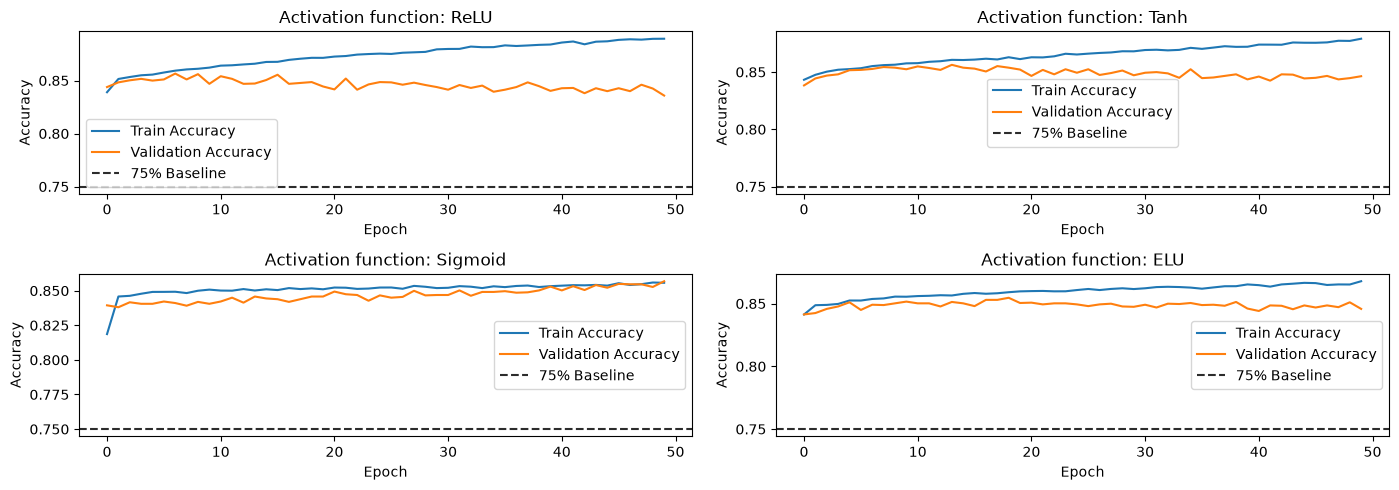

In [21]:
# 3.2 Activation comparison - 4-panel plot

fig, ax = plt.subplots(2,2, figsize = (14,5))

histories = [history_relu, history_tanh, history_sigmoid, history_elu]
activation_names = ['ReLU', 'Tanh', 'Sigmoid', 'ELU']

for i, history in enumerate(histories):
    row = i // 2
    col = i % 2

    ax[row,col].plot(history.history['accuracy'], label='Train Accuracy')
    ax[row,col].plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax[row,col].set_title(f"Activation function: {activation_names[i]}")
    ax[row, col].axhline(
        y=0.75,
        linestyle='--',
        color='#2C2C2C',
        label='75% Baseline'
    )
    ax[row,col].set_xlabel('Epoch')
    ax[row,col].set_ylabel('Accuracy')
    ax[row,col].legend()

plt.tight_layout()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Fraction of dead activations (ReLU, first hidden layer): 0.5933


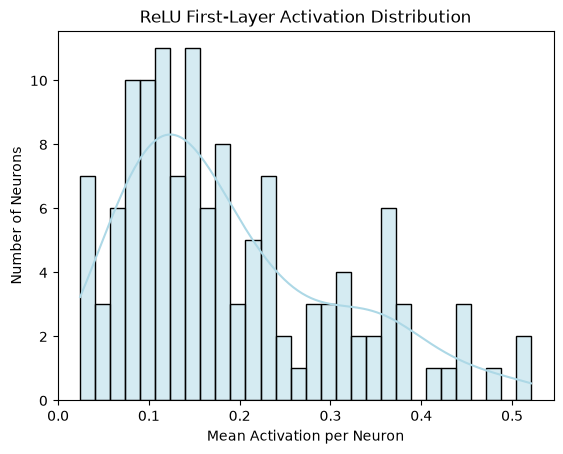

In [31]:
# 3.3 Dead neuron check - ReLU

inp = Input(shape = (X_train.shape[1],))
out = model_relu.layers[0](inp)

intermediate = Model(inputs = inp, outputs = out)
activations = intermediate.predict(X_test[:500])
dead_fraction = np.mean(activations == 0)
print(f"Fraction of dead activations (ReLU, first hidden layer): {dead_fraction:.4f}")


mean_activation_per_neuron = activations.mean(axis = 0)
sns.histplot(x = mean_activation_per_neuron, bins = 30, kde = True, color = 'lightblue')
plt.title('ReLU First-Layer Activation Distribution')
plt.xlabel('Mean Activation per Neuron')
plt.ylabel('Number of Neurons')
plt.show()

In [ ]:
# 3.4 Gradient flow check - Sigmoid hidden layers


In [ ]:
# 3.5 Activation summary Markdown table

### Task 4: Weight Initialization Techniques

In [32]:
# 4.1 Train 5 models with different initialisers

model_glorot_uniform = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'glorot_uniform')
model_glorot_normal  = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'glorot_normal')
model_he_uniform     = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_uniform')
model_he_normal      = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal')
model_zeros          = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'zeros')

history_glorot_uniform = model_glorot_uniform.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_glorot_normal  = model_glorot_normal.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_he_uniform     = model_he_uniform.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_he_normal      = model_he_normal.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)
history_zeros          = model_zeros.fit(X_train, y_train, epochs = 50, batch_size = 64, validation_split = 0.1, verbose = 1)


Epoch 1/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8403 - loss: 0.3370 - val_accuracy: 0.8460 - val_loss: 0.3211
Epoch 2/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8512 - loss: 0.3163 - val_accuracy: 0.8449 - val_loss: 0.3213
Epoch 3/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8542 - loss: 0.3124 - val_accuracy: 0.8458 - val_loss: 0.3237
Epoch 4/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8554 - loss: 0.3093 - val_accuracy: 0.8491 - val_loss: 0.3225
Epoch 5/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8564 - loss: 0.3062 - val_accuracy: 0.8485 - val_loss: 0.3247
Epoch 6/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8571 - loss: 0.3043 - val_accuracy: 0.8483 - val_loss: 0.3206
Epoch 7/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8597 - loss: 0.3018 - val_accuracy: 0.8507 - val_loss: 0.3262
Epoch 8/50
509/509 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8604 - loss: 0.2992 - val_accuracy: 0.

In [ ]:
# 4.2 Why initialisation matters - Markdown

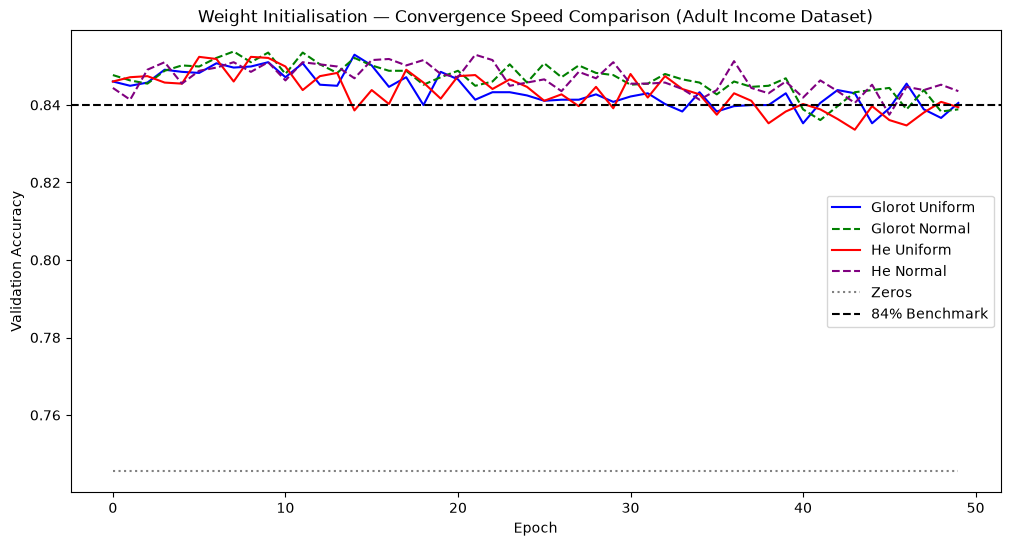

In [34]:
# 4.3 Convergence speed comparison plot

plt.figure(figsize=(12, 6))

plt.plot(history_glorot_uniform.history['val_accuracy'], label='Glorot Uniform', color='blue', linestyle='-')
plt.plot(history_glorot_normal.history['val_accuracy'], label='Glorot Normal', color='green', linestyle='--')
plt.plot(history_he_uniform.history['val_accuracy'], label='He Uniform', color='red', linestyle='-')
plt.plot(history_he_normal.history['val_accuracy'], label='He Normal', color='purple', linestyle='--')
plt.plot(history_zeros.history['val_accuracy'], label='Zeros', color='gray', linestyle=':')

plt.axhline(y=0.84, color='black', linestyle='--', label='84% Benchmark')

plt.title('Weight Initialisation — Convergence Speed Comparison (Adult Income Dataset)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

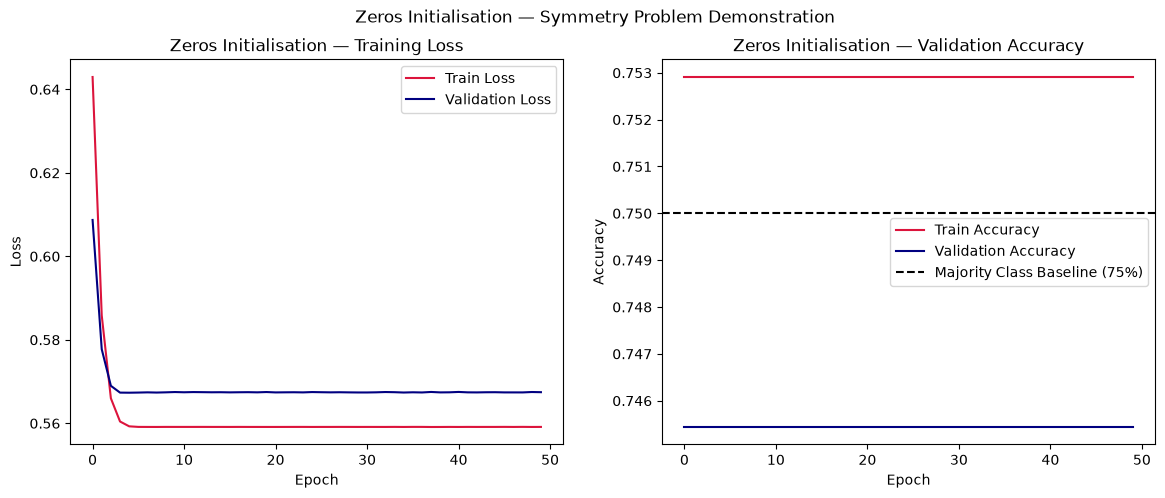

In [35]:
# 4.4 Zeros failure demonstration

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history_zeros.history['loss'], label='Train Loss', color='crimson')
ax[0].plot(history_zeros.history['val_loss'], label='Validation Loss', color='navy')
ax[0].set_title('Zeros Initialisation — Training Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()

ax[1].plot(history_zeros.history['accuracy'], label='Train Accuracy', color='crimson')
ax[1].plot(history_zeros.history['val_accuracy'], label='Validation Accuracy', color='navy')
ax[1].axhline(y=0.75, color='black', linestyle='--', label='Majority Class Baseline (75%)')
ax[1].set_title('Zeros Initialisation — Validation Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.suptitle('Zeros Initialisation — Symmetry Problem Demonstration')
plt.show()

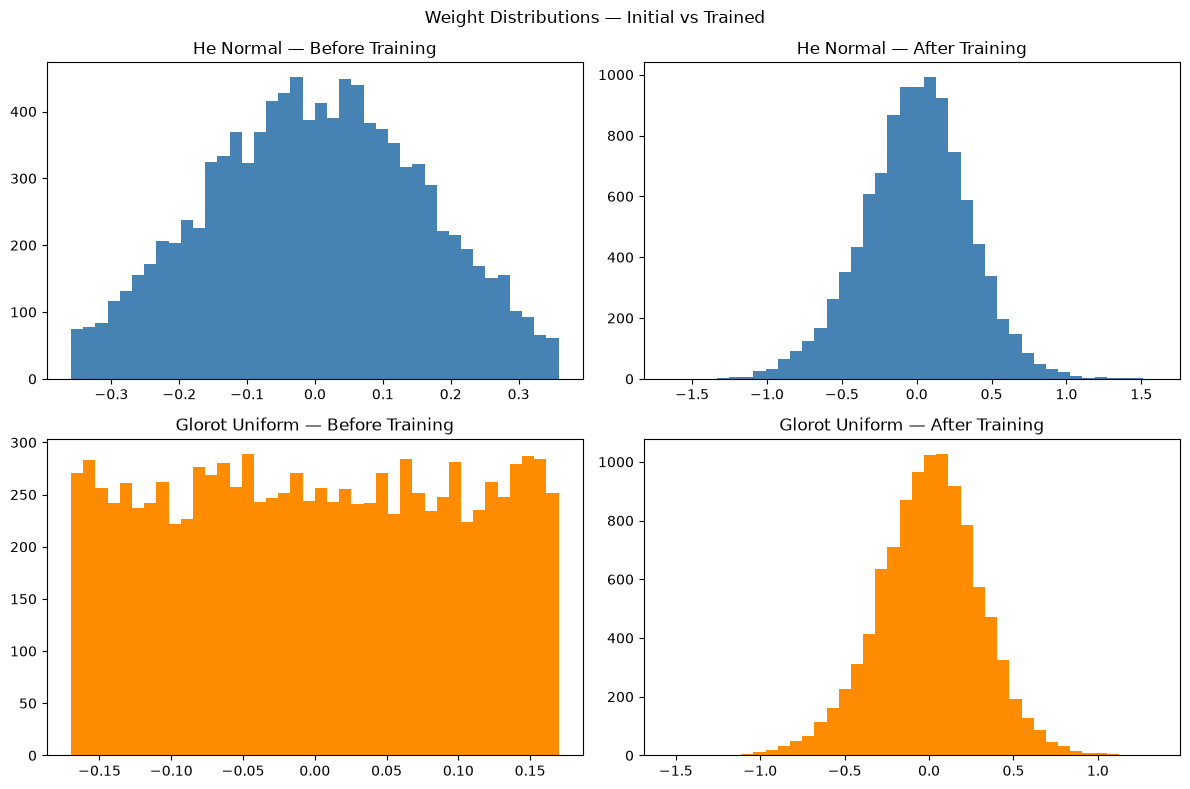

In [36]:
# 4.5 Weight distribution visualisation

model_he_normal_init = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'he_normal')
model_glorot_uniform_init = build_ann(input_dim = X_train.shape[1], activation = 'relu', initializer = 'glorot_uniform')

he_weights_before = model_he_normal_init.layers[0].get_weights()[0].flatten()
glorot_weights_before = model_glorot_uniform_init.layers[0].get_weights()[0].flatten()


he_weights_after = model_he_normal.layers[0].get_weights()[0].flatten()
glorot_weights_after = model_glorot_uniform.layers[0].get_weights()[0].flatten()

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].hist(he_weights_before, bins=40, color='steelblue')
ax[0,0].set_title('He Normal — Before Training')

ax[0,1].hist(he_weights_after, bins=40, color='steelblue')
ax[0,1].set_title('He Normal — After Training')

ax[1,0].hist(glorot_weights_before, bins=40, color='darkorange')
ax[1,0].set_title('Glorot Uniform — Before Training')

ax[1,1].hist(glorot_weights_after, bins=40, color='darkorange')
ax[1,1].set_title('Glorot Uniform — After Training')

plt.suptitle('Weight Distributions — Initial vs Trained')
plt.tight_layout()
plt.show()